Fetching MNIST dataset... (this takes a moment)
Epoch 0 | Mean Squared Error: 0.2141
Epoch 200 | Mean Squared Error: 0.1238
Epoch 400 | Mean Squared Error: 0.0989
Epoch 600 | Mean Squared Error: 0.0910
Epoch 800 | Mean Squared Error: 0.0878


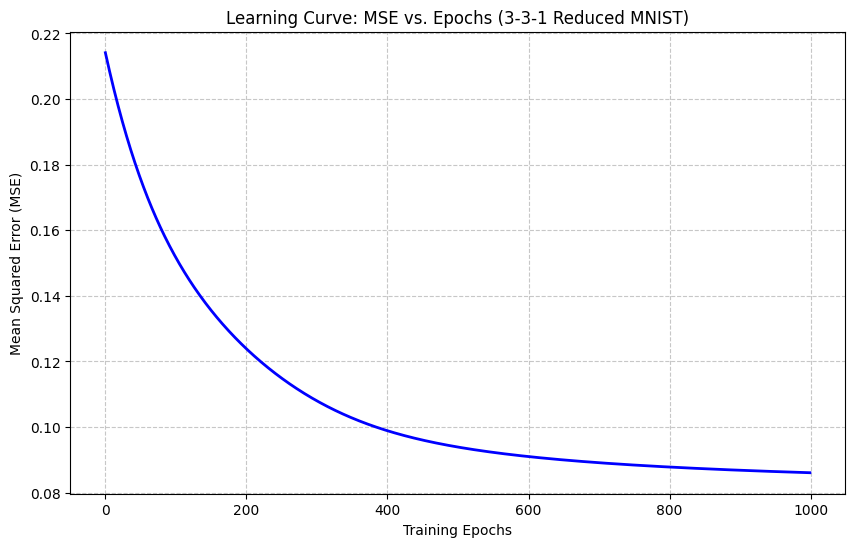

Training Complete. The network has learned the weight matrices!


In [2]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ==========================================
# 1. Data Preparation (Satisfying the 3x3x1 requirement)
# ==========================================
print("Fetching MNIST dataset... (this takes a moment)")
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X_raw = mnist.data.astype('float32')
y_raw = mnist.target.astype('int')

# Binary classification: 1 if the digit is '5', 0 otherwise
y = np.where(y_raw == 5, 1, 0).reshape(-1, 1)

# Standardize data and reduce to exactly 3 input features using PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca = PCA(n_components=3)
X_features = pca.fit_transform(X_scaled)

# Split into a small training set for demonstration
X_train, _, y_train, _ = train_test_split(X_features, y, train_size=1000, random_state=42)

# ==========================================
# 2. Neural Network Architecture (3 -> 3 -> 1)
# ==========================================
# Activation function and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    # This derivative expects 'x' to already be sigmoid output (A)
    return x * (1 - x)

# Initialize weights randomly
np.random.seed(42)
W1 = np.random.randn(3, 3) # Input to Hidden (3 inputs, 3 hidden nodes)
W2 = np.random.randn(3, 1) # Hidden to Output (3 hidden nodes, 1 output node)

learning_rate = 0.1
epochs = 1000
mse_history = [] # To store error for plotting

# ==========================================
# 3. Training Loop (Forward, Error, Backprop, Update)
# ==========================================
for epoch in range(epochs):
    # --- A. FORWARD PASS ---
    # Input to Hidden Layer (Z1 is weighted sum, A1 is activation)
    Z1 = np.dot(X_train, W1)
    A1 = sigmoid(Z1)

    # Hidden to Output Layer (Z2 is weighted sum, A2 is final prediction)
    Z2 = np.dot(A1, W2)
    A2 = sigmoid(Z2)

    # --- B. CALCULATE THE ERROR ---
    # Core error (difference)
    error = A2 - y_train

    # Track Mean Squared Error for the curve
    mse = np.mean(np.square(error))
    mse_history.append(mse)

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Mean Squared Error: {mse:.4f}")

    # --- C. BACKPROPAGATION (Using Matrix Transpositions) ---
    # 1. Gradients at Output Layer (calculating dZ2)
    dZ2 = error * sigmoid_derivative(A2)

    # dW2: Needs shape (3,1). A1 is (1000,3), dZ2 is (1000,1).
    # We transpose A1 (3x1000) to multiply by dZ2 (1000x1).
    dW2 = np.dot(A1.T, dZ2) / len(X_train)

    # 2. Gradients at Hidden Layer (Routing error back)
    # Transpose W2 (3x1 -> 1x3) to route dZ2 (1000x1) back to the 3 hidden nodes.
    # Results in (1000x3) dZ1.
    dZ1 = np.dot(dZ2, W2.T) * sigmoid_derivative(A1)

    # dW1: Needs shape (3,3). X_train is (1000,3), dZ1 is (1000,3).
    # We transpose X_train (3x1000) to multiply by dZ1 (1000x3).
    dW1 = np.dot(X_train.T, dZ1) / len(X_train)

    # --- D. UPDATE WEIGHT MATRICES (Optimization) ---
    W2 -= learning_rate * dW2
    W1 -= learning_rate * dW1

# ==========================================
# 4. Plotting the Learning Curve
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(mse_history, color='blue', linewidth=2)
plt.title("Learning Curve: MSE vs. Epochs (3-3-1 Reduced MNIST)")
plt.xlabel("Training Epochs")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Training Complete. The network has learned the weight matrices!")